# 🤟 Sign Language MNIST — Aumento de imágenes y CNN con PyTorch
## Reto proyecto 2 · Aplica técnicas de aumento de imágenes y entrena una CNN para reconocer el lenguaje de signos

---

Este notebook aplica **6 técnicas de aumento de imágenes** sobre el dataset *Sign Language MNIST*  
y entrena una **red neuronal convolucional (CNN)** desde cero para clasificar letras del alfabeto  
en lenguaje de signos americano (ASL), explorando además el efecto de distintas configuraciones  
de capas convolucionales sobre las dimensiones de salida.

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Instalación e importaciones |
| 2️⃣ | Descarga del dataset desde Kaggle (kagglehub) |
| 3️⃣ | Carga desde CSV con Pandas → arrays NumPy 28×28 |
| 4️⃣ | Aplicación de **6 transformaciones** a una imagen: rotación, traslación, escalado, inversión de colores, ruido gaussiano y recorte aleatorio |
| 5️⃣ | Visualización comparativa original vs. transformadas |
| 6️⃣ | Dataset personalizado, split 80/20 y DataLoader (batch_size=32) |
| 7️⃣ | Función auxiliar de dimensiones + exploración de 4 configuraciones CNN (padding, stride, kernel, pooling) |
| 8️⃣ | Arquitectura CNN final (2 capas conv + BN + pooling + FC) |
| 9️⃣ | Entrenamiento 10 épocas · Adam · pérdida y precisión train/val por época |
| 🔟 | Curvas de aprendizaje y evaluación final por clase |

> **Dataset:** *Sign Language MNIST* — 27.455 imágenes · 24 clases (letras A–Z, sin J ni Z)  
> **Formato:** CSV con 784 columnas de píxeles (imágenes 28×28 en escala de grises)  
> **Objetivo:** clasificación multiclase de gestos del alfabeto ASL  
> **Entorno:** Kaggle (GPU disponible · descarga automática con kagglehub)

## 1. Instalación e importaciones

In [12]:
%pip install torch torchvision matplotlib kagglehub scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.


In [13]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"  # errores CUDA síncronos

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Fijar todas las semillas para máxima reproducibilidad ─────────────────────
SEED = 42
np.random.seed(SEED)                      # NumPy
torch.manual_seed(SEED)                   # CPU de PyTorch
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)      # todas las GPUs
    torch.backends.cudnn.deterministic = True   # operaciones deterministas
    torch.backends.cudnn.benchmark     = False  # desactiva autotuner no determinista

print(f'Dispositivo : {device}')
print(f'Semilla fijada: CPU={SEED}, NumPy={SEED}' +
      (f', CUDA (todas las GPUs)={SEED}' if torch.cuda.is_available() else ''))

Dispositivo : cuda
Semilla fijada: CPU=42, NumPy=42, CUDA (todas las GPUs)=42


## 2. Descarga del dataset (kagglehub)

In [14]:
import kagglehub

# ---------------------------------------------------------------------------
# CONFIGURACIÓN DE RUTA AL DATASET
# ---------------------------------------------------------------------------
# Si tienes los CSV descargados en tu máquina, pon la carpeta en LOCAL_PATH.
# Estructura esperada:
#   <LOCAL_PATH>/
#     sign_mnist_train.csv
#     sign_mnist_test.csv
#
# Si LOCAL_PATH está vacío (''), el notebook descarga automáticamente
# el dataset desde Kaggle mediante kagglehub (requiere credenciales Kaggle).
# ---------------------------------------------------------------------------
LOCAL_PATH = ''   # ← p. ej. '/datos/sign-language-mnist'

if LOCAL_PATH:
    # Ruta local explícita: no se necesita kagglehub ni conexión a internet
    dataset_path = LOCAL_PATH
    print(f'Usando dataset local en: {dataset_path}')
else:
    # Descarga automática desde Kaggle
    dataset_path = kagglehub.dataset_download('datamunge/sign-language-mnist')
    print(f'Dataset descargado en: {dataset_path}')

# Localizar los CSV de train y test dentro de la carpeta
train_csv = test_csv = None
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        full = os.path.join(root, f)
        if 'train' in f and f.endswith('.csv'):
            train_csv = full
        elif 'test' in f and f.endswith('.csv'):
            test_csv = full

print(f'Train CSV : {train_csv}')
print(f'Test  CSV : {test_csv}')

Dataset descargado en: /kaggle/input/datasets/datamunge/sign-language-mnist
Train CSV : /kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train/sign_mnist_train.csv
Test  CSV : /kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv


## 3. Carga desde CSV y preprocesado

Cada fila del CSV contiene una etiqueta (`label`) y 784 columnas de píxeles  
(imagen 28×28 en escala de grises, valores 0–255).

In [15]:
# --- Carga con Pandas ---
df_train = pd.read_csv(train_csv)
df_test  = pd.read_csv(test_csv)

# Comprobar etiquetas.
print(f"Etiquetas: {sorted(df_train['label'].unique())}")

# Las etiquetas del CSV tienen huecos (faltan J=9 y Z=25).
# LabelEncoder las remapea automáticamente a índices continuos [0, 23].
le = LabelEncoder()
labels_train = le.fit_transform(df_train['label'])
labels_test  = le.transform(df_test['label'])

# Píxeles → array (N, 28, 28) float32
images_train = df_train.drop(columns='label').to_numpy().reshape(-1, 28, 28).astype(np.float32)
images_test  = df_test.drop(columns='label').to_numpy().reshape(-1, 28, 28).astype(np.float32)

# Mapa de clases: índice → letra (sin J=9, Z=25)
CLASS_LETTERS = [chr(ord('A') + i) for i in range(26) if i not in (9, 25)]
num_classes   = len(CLASS_LETTERS)

print(f'Imágenes train : {images_train.shape}  |  Etiquetas: {labels_train.shape}')
print(f'Imágenes test  : {images_test.shape}   |  Etiquetas: {labels_test.shape}')
print(f'Clases ({num_classes})      : {CLASS_LETTERS}')
print(f'Rango de píxeles: [{images_train.min():.0f}, {images_train.max():.0f}]')

Etiquetas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Imágenes train : (27455, 28, 28)  |  Etiquetas: (27455,)
Imágenes test  : (7172, 28, 28)   |  Etiquetas: (7172,)
Clases (24)      : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Rango de píxeles: [0, 255]


## 4. Selección de imagen y aplicación de 6 transformaciones

Se aplican **6 transformaciones** distintas a la primera imagen del dataset:

| # | Transformación | Descripción |
|---|---------------|-------------|
| 1 | **Rotación** | `RandomRotation(30°)` — giro aleatorio ±30° |
| 2 | **Traslación** | `RandomAffine(translate)` — desplazamiento hasta 20% |
| 3 | **Escalado** | `RandomAffine(scale)` — zoom entre 0.75× y 1.25× |
| 4 | **Inversión de colores** | `RandomInvert` — negativo de la imagen |
| 5 | **Ruido gaussiano** | Adición de ruido N(0, 0.15) sobre el tensor normalizado |
| 6 | **Recorte aleatorio** | `RandomResizedCrop(28)` — recorte y redimensión |

In [16]:
# Imagen de referencia: primera muestra del train
sample_idx   = 0
sample_img   = images_train[sample_idx]          # (28, 28) float32  0-255
sample_label = labels_train[sample_idx]

# Convertir a tensor PIL-compatible: (1, 28, 28)
to_pil    = T.ToPILImage()
to_tensor = T.ToTensor()

img_tensor = torch.from_numpy(sample_img).unsqueeze(0) / 255.0   # (1, 28, 28)
img_pil    = to_pil(img_tensor)

# ── Transformación personalizada: Ruido Gaussiano ─────────────────────────────
class GaussianNoise(torch.nn.Module):
    """
    Añade ruido gaussiano N(0, sigma) a un tensor de imagen en [0, 1].
    Al heredar de nn.Module queda integrado en cualquier T.Compose
    exactamente igual que el resto de transforms de torchvision.
    """
    def __init__(self, sigma: float = 0.15):
        super().__init__()
        self.sigma = sigma

    def forward(self, tensor: torch.Tensor) -> torch.Tensor:
        noise = torch.randn_like(tensor) * self.sigma
        return (tensor + noise).clamp(0, 1)

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}(sigma={self.sigma})'

# ── Definición de las 6 transformaciones con parámetros FIJOS ─────────────────
# Se usan parámetros explícitos (no aleatorios) donde es posible, para que
# la visualización sea idéntica en cada ejecución.

# 1. Rotación — ángulo fijo de 20° (determinista)
img_rot = TF.rotate(img_pil, angle=20)
img_rot = T.ToTensor()(img_rot)

# 2. Traslación — desplazamiento fijo de 5 px horizontal, 3 px vertical
img_trans = TF.affine(img_pil, angle=0, translate=(5, 3), scale=1.0, shear=0)
img_trans = T.ToTensor()(img_trans)

# 3. Escalado — factor fijo de 0.85×
img_scale = TF.affine(img_pil, angle=0, translate=(0, 0), scale=0.85, shear=0)
img_scale = T.ToTensor()(img_scale)

# 4. Inversión de colores — determinista por naturaleza
img_inv = TF.invert(img_pil)
img_inv = T.ToTensor()(img_inv)

# 5. Ruido gaussiano — semilla local fija sin alterar el estado global del RNG
_rng_state = torch.get_rng_state()
torch.manual_seed(SEED)
tf_noise  = T.Compose([T.ToTensor(), GaussianNoise(sigma=0.15)])
img_noise = tf_noise(img_pil)
torch.set_rng_state(_rng_state)

# 6. Recorte — escala fija (0.6) con semilla local
_rng_state = torch.get_rng_state()
torch.manual_seed(SEED)
img_crop = T.Compose([T.RandomResizedCrop(28, scale=(0.6, 0.6)), T.ToTensor()])(img_pil)
torch.set_rng_state(_rng_state)

transformations = [
    (img_tensor,  'Original'),
    (img_rot,     '1. Rotación (20°)'),
    (img_trans,   '2. Traslación (+5,+3 px)'),
    (img_scale,   '3. Escalado (0.85x)'),
    (img_inv,     '4. Inversión de colores'),
    (img_noise,   '5. Ruido gaussiano'),
    (img_crop,    '6. Recorte (scale=0.6)'),
]

print(f'Imagen — índice {sample_idx}, clase: {CLASS_LETTERS[sample_label]} (label={sample_label})')
print('Transformaciones con parámetros FIJOS — reproducibles en cada ejecución.')

Imagen — índice 0, clase: D (label=3)
Transformaciones con parámetros FIJOS — reproducibles en cada ejecución.


## 5. Visualización comparativa

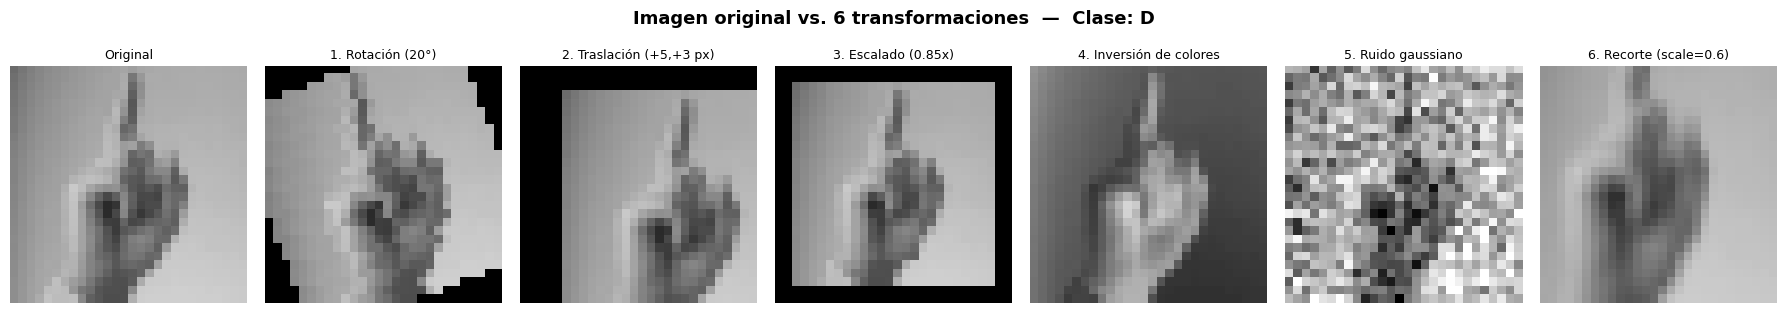

In [17]:
fig, axes = plt.subplots(1, 7, figsize=(18, 3))
fig.suptitle(
    f'Imagen original vs. 6 transformaciones  —  Clase: {CLASS_LETTERS[sample_label]}',
    fontsize=13, fontweight='bold', y=1.03
)

for ax, (img_t, title) in zip(axes, transformations):
    arr = img_t.squeeze().numpy()
    ax.imshow(arr, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
    if title == 'Original':
        for spine in ax.spines.values():
            spine.set_edgecolor('#2196F3')
            spine.set_linewidth(2)
            ax.set_visible(True)

plt.tight_layout()
plt.show()

### 5.1 Histogramas de intensidad por transformación

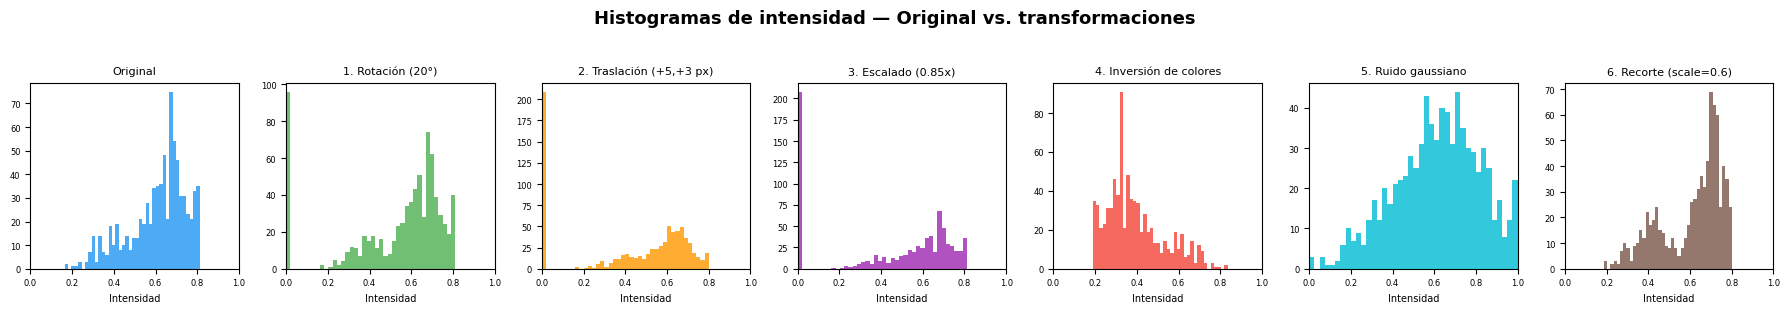

In [18]:
# ── Histogramas de intensidad — efecto cuantitativo de cada transformación ────
fig, axes = plt.subplots(1, 7, figsize=(18, 3), sharey=False)
fig.suptitle('Histogramas de intensidad — Original vs. transformaciones',
             fontsize=13, fontweight='bold', y=1.03)

colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4','#795548']

for ax, (img_t, title), color in zip(axes, transformations, colors):
    vals = img_t.squeeze().numpy().flatten()
    ax.hist(vals, bins=40, color=color, alpha=0.8, edgecolor='none')
    ax.set_title(title, fontsize=8)
    ax.set_xlabel('Intensidad', fontsize=7)
    ax.set_xlim(0, 1)
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

## 6. Dataset, split 80/20 y DataLoader

Se normaliza cada imagen con la media y desviación estándar del propio dataset  
y se divide en 80% entrenamiento / 20% validación.

In [19]:
class SignLanguageDataset(Dataset):
    """Dataset Sign Language MNIST desde arrays NumPy."""
    def __init__(self, images, labels, transform=None):
        self.images    = images          # (N, 28, 28) float32  0-255
        self.labels    = labels.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img   = self.images[idx] / 255.0                  # [0, 1]
        img_t = torch.from_numpy(img).unsqueeze(0)        # (1, 28, 28)
        if self.transform:
            img_t = self.transform(img_t)
        return img_t, self.labels[idx]


# ── Funciones reutilizables ───────────────────────────────────────────────────

def compute_stats(images: np.ndarray):
    """Media y desviación estándar normalizadas a [0,1]. Reutilizable para
    cualquier subconjunto o dataset."""
    return images.mean() / 255.0, images.std() / 255.0


def make_loaders(images_tr, labels_tr, images_te, labels_te,
                 val_split=0.2, batch_size=32, seed=42, augment=True):
    """
    Construye train_loader, val_loader y test_dataset.

    Parámetros
    ----------
    val_split  : fracción del train para validación (por defecto 0.20)
    batch_size : tamaño de lote (por defecto 32)
    seed       : semilla reproducible
    augment    : si True, aplica data augmentation al train (rotación + traslación)

    Devuelve
    --------
    train_loader, val_loader, test_dataset, (train_size, val_size)
    """
    mean, std = compute_stats(images_tr)
    norm      = T.Normalize(mean=[mean], std=[std])

    # Pipeline de augmentation para train: rotación suave + traslación pequeña
    # ANTES de la normalización para no distorsionar los valores normalizados.
    if augment:
        aug = T.Compose([
            T.ToPILImage(),
            T.RandomRotation(degrees=10),
            T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            T.ToTensor(),
            norm
        ])
    else:
        aug = norm

    full_aug  = SignLanguageDataset(images_tr, labels_tr, transform=aug)
    full_norm = SignLanguageDataset(images_tr, labels_tr, transform=norm)
    test_ds   = SignLanguageDataset(images_te, labels_te, transform=norm)

    # Mismo split de índices para train (con aug) y val (sin aug)
    total      = len(full_aug)
    val_size   = int(val_split * total)
    train_size = total - val_size
    indices    = torch.randperm(total, generator=torch.Generator().manual_seed(seed)).tolist()
    tr_idx, val_idx = indices[:train_size], indices[train_size:]

    from torch.utils.data import Subset
    train_ds = Subset(full_aug,  tr_idx)   # train CON augmentation
    val_ds   = Subset(full_norm, val_idx)  # val SIN augmentation

    tr_loader  = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2)
    val_loader = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2)

    return tr_loader, val_loader, test_ds, (train_size, val_size)


# ── Uso con los parámetros del enunciado (80/20, batch=32, con augmentation) ──
mean_val, std_val = compute_stats(images_train)
print(f'Media: {mean_val:.4f}  |  Desv. típica: {std_val:.4f}')

train_loader, val_loader, test_dataset, (train_size, val_size) = make_loaders(
    images_train, labels_train,
    images_test,  labels_test,
    val_split=0.2, batch_size=32, seed=SEED, augment=True
)

print(f'Train: {train_size} imagenes (CON augmentation)  |  Val: {val_size} (sin augmentation)')
print(f'Lotes train: {len(train_loader)}  |  Lotes val: {len(val_loader)}')

Media: 0.6247  |  Desv. típica: 0.1913
Train: 21964 imagenes (CON augmentation)  |  Val: 5491 (sin augmentation)
Lotes train: 687  |  Lotes val: 172


## 7. Función auxiliar de dimensiones y exploración de configuraciones CNN

La función `conv_out_size` calcula la dimensión espacial de salida tras aplicar  
una capa Conv2d (o MaxPool2d) con la fórmula estándar:

$$H_{out} = \left\lfloor \frac{H_{in} + 2 \cdot padding - kernel\_size}{stride} + 1 \right\rfloor$$

Se prueban **4 configuraciones** distintas modificando `padding`, `stride`, `kernel_size`  
y el tamaño del pooling, tal como exige el enunciado.

In [20]:
def conv_out_size(h_in, kernel_size, stride=1, padding=0):
    """
    Dimensión de salida de una capa Conv2d o MaxPool2d.

    Parámetros
    ----------
    h_in        : dimensión de entrada (altura o anchura)
    kernel_size : tamaño del kernel
    stride      : stride (por defecto 1)
    padding     : relleno (por defecto 0)

    Devuelve
    --------
    h_out : int  (usando floor)
    """
    return math.floor((h_in + 2 * padding - kernel_size) / stride + 1)


configs = [
    # (descripción,           k1, s1, p1,  k2, s2, p2,  pool_k, pool_s)
    ('kernel=3 s=1 pad=0 pool=2x2', 3, 1, 0,  3, 1, 0,  2, 2),
    ('kernel=3 s=1 pad=1 pool=2x2', 3, 1, 1,  3, 1, 1,  2, 2),
    ('kernel=5 s=1 pad=0 pool=2x2', 5, 1, 0,  5, 1, 0,  2, 2),
    ('kernel=3 s=2 pad=0 pool=4x4', 3, 2, 0,  3, 2, 0,  4, 4),
]

print('Exploración de configuraciones CNN — entrada 28x28')
print()

# Cabecera de la tabla
col = '{:<28} {:>8} {:>8} {:>8} {:>8} {:>10} {}'
print(col.format('Configuración', 'h_conv1', 'h_pool1', 'h_conv2', 'h_pool2', 'flatten', 'estado'))
print('-' * 85)

for desc, k1, s1, p1, k2, s2, p2, pk, ps in configs:
    h_conv1 = conv_out_size(28,     k1, s1, p1)
    h_pool1 = conv_out_size(h_conv1, pk, ps, 0)
    h_conv2 = conv_out_size(h_pool1, k2, s2, p2)
    h_pool2 = conv_out_size(h_conv2, pk, ps, 0)
    flat    = 64 * h_pool2 * h_pool2 if h_pool2 > 0 else 0
    status  = 'OK' if h_pool2 > 0 else 'COLAPSO'
    print(col.format(desc, h_conv1, h_pool1, h_conv2, h_pool2, flat, status))

Exploración de configuraciones CNN — entrada 28x28

Configuración                 h_conv1  h_pool1  h_conv2  h_pool2    flatten estado
-------------------------------------------------------------------------------------
kernel=3 s=1 pad=0 pool=2x2        26       13       11        5       1600 OK
kernel=3 s=1 pad=1 pool=2x2        28       14       14        7       3136 OK
kernel=5 s=1 pad=0 pool=2x2        24       12        8        4       1024 OK
kernel=3 s=2 pad=0 pool=4x4        13        3        1        0          0 COLAPSO


## 8. Arquitectura CNN final

Se elige la configuración `kernel=3, stride=1, padding=1, pool=2×2` por ser  
la más estable (sin colapso de dimensiones) y la más común en la literatura:

```
Input (1, 28, 28)
  └─ Conv1(1→32, k=3, s=1, p=1) + BN + ReLU + MaxPool(2,2)  →  (32, 14, 14)
  └─ Conv2(32→64, k=3, s=1, p=1) + BN + ReLU + MaxPool(2,2) →  (64,  7,  7)
  └─ Flatten  →  3136
  └─ FC1(3136→256) + ReLU + Dropout(0.5)
  └─ FC2(256→24)   →  logits
```

In [21]:
# ── Función auxiliar: deriva flatten automáticamente ─────────────────────────
INPUT_H       = 28
CONV_CHANNELS = [1, 32, 64]

def compute_flatten(input_h, k1, s1, p1, k2, s2, p2, pk, ps, pool2_active=True):
    h = conv_out_size(input_h, k1, s1, p1)
    h = conv_out_size(h,       pk, ps, 0)     # Pool1 siempre activo
    h = conv_out_size(h,       k2, s2, p2)
    if pool2_active:
        h = conv_out_size(h,   pk, ps, 0)     # Pool2 opcional
    return CONV_CHANNELS[-1] * h * h


# ── Modelo parametrizado con pool2 opcional ───────────────────────────────────
class SignCNN(nn.Module):
    """
    CNN parametrizada: kernel_size, stride, padding, pool_kernel y pool2_active
    se pasan en el constructor, conectando directamente con la exploración previa.
    pool2_active=False desactiva el segundo MaxPool para experimentar con
    distintas profundidades sin redefinir la arquitectura.
    """
    def __init__(self, num_classes=24,
                 kernel_size=3, stride=1, padding=1, pool_kernel=2,
                 pool2_active=True):
        super().__init__()
        pool_stride       = pool_kernel
        self.pool2_active = pool2_active

        flat = compute_flatten(INPUT_H,
                               kernel_size, stride, padding,
                               kernel_size, stride, padding,
                               pool_kernel, pool_stride,
                               pool2_active=pool2_active)
        if flat <= 0:
            raise ValueError(
                f'Config (k={kernel_size}, s={stride}, p={padding}, '
                f'pool={pool_kernel}) colapsa las dimensiones.')

        # Bloque conv 1: (1,28,28) → Conv → (32,28,28) → Pool → (32,14,14)
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=pool_kernel, stride=pool_stride)
            # salida: (32,14,14) con k=3,s=1,p=1,pool=2
        )
        # Bloque conv 2: (32,14,14) → Conv → (64,14,14) → [Pool → (64,7,7)]
        self.conv2_conv = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(64),
            nn.ReLU()
            # salida conv: (64,14,14); tras pool2 opcional: (64,7,7)
        )
        self.pool2 = nn.MaxPool2d(kernel_size=pool_kernel, stride=pool_stride)

        # Clasificador: flatten → FC(256) → Dropout(0.5) → FC(num_classes)
        self.classifier = nn.Sequential(
            nn.Flatten(),                  # (64,7,7)→3136 o (64,14,14)→12544
            nn.Linear(flat, 256),          # dimensión calculada por compute_flatten
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)    # logit por clase
        )
        self._flat = flat

    def forward(self, x):
        x = self.conv1(x)                      # (B,1,28,28)→(B,32,14,14)
        x = self.conv2_conv(x)                 # (B,32,14,14)→(B,64,14,14)
        if self.pool2_active:
            x = self.pool2(x)                  # (B,64,14,14)→(B,64,7,7)
        return self.classifier(x)


# ── Instanciar las 4 configuraciones + variante sin pool2 ────────────────────
print('Configuraciones evaluadas:')
print()
cfg_params = [
    dict(kernel_size=3, stride=1, padding=0, pool_kernel=2, pool2_active=True),
    dict(kernel_size=3, stride=1, padding=1, pool_kernel=2, pool2_active=True),  # final
    dict(kernel_size=5, stride=1, padding=0, pool_kernel=2, pool2_active=True),
    dict(kernel_size=3, stride=2, padding=0, pool_kernel=4, pool2_active=True),
    dict(kernel_size=3, stride=1, padding=1, pool_kernel=2, pool2_active=False), # sin pool2
]
for cfg in cfg_params:
    try:
        m      = SignCNN(num_classes=num_classes, **cfg)
        params = sum(p.numel() for p in m.parameters())
        p2     = 'pool2=ON ' if cfg['pool2_active'] else 'pool2=OFF'
        print(f'  k={cfg["kernel_size"]} s={cfg["stride"]} p={cfg["padding"]} '
              f'pool={cfg["pool_kernel"]} {p2}  ->  flatten={m._flat:,}  params={params:,}')
    except ValueError as e:
        print(f'  [COLAPSO] {e}')

print()
print('Modelo final: k=3, s=1, p=1, pool=2, pool2=ON')
model = SignCNN(num_classes=num_classes,
                kernel_size=3, stride=1, padding=1,
                pool_kernel=2, pool2_active=True).to(device)
print(model)
print(f'\nParametros totales: {sum(p.numel() for p in model.parameters()):,}')

Configuraciones evaluadas:

  k=3 s=1 p=0 pool=2 pool2=ON   ->  flatten=1,600  params=435,032
  k=3 s=1 p=1 pool=2 pool2=ON   ->  flatten=3,136  params=828,248
  k=5 s=1 p=0 pool=2 pool2=ON   ->  flatten=1,024  params=320,856
  [COLAPSO] Config (k=3, s=2, p=0, pool=4) colapsa las dimensiones.
  k=3 s=1 p=1 pool=2 pool2=OFF  ->  flatten=12,544  params=3,236,696

Modelo final: k=3, s=1, p=1, pool=2, pool2=ON
SignCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2_conv): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=

## 9. Entrenamiento — ≥5 épocas · Adam · pérdida y precisión por época

In [22]:
import copy

criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
NUM_EPOCHS = 10

# ReduceLROnPlateau: reduce lr x0.5 si val_loss no mejora en 3 épocas
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# Early stopping: para si val_loss no mejora en 5 épocas consecutivas
EARLY_STOP_PATIENCE = 5
no_improve_epochs   = 0
best_val_loss_es    = float('inf')

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

best_val_acc  = 0.0
best_epoch    = 0
best_weights  = None

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Fase entrenamiento ────────────────────────────────────────────────────
    model.train()
    running_loss = correct = total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = 100.0 * correct / total

    # ── Fase validación ───────────────────────────────────────────────────────
    model.eval()
    v_loss = v_correct = v_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs   = model(images)
            v_loss   += criterion(outputs, labels).item()
            preds     = outputs.argmax(dim=1)
            v_correct += (preds == labels).sum().item()
            v_total   += labels.size(0)

    val_loss = v_loss / len(val_loader)
    val_acc  = 100.0 * v_correct / v_total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Scheduler
    scheduler.step(val_loss)

    # Guardar mejor modelo por val_acc
    marker = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, 'best_model.pth')
        marker = '  ⭐ mejor val'

    # Early stopping
    if val_loss < best_val_loss_es:
        best_val_loss_es  = val_loss
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1

    lr_actual = optimizer.param_groups[0]['lr']
    print(f'Epoca {epoch:>2}/{NUM_EPOCHS}  '
          f'| Train loss: {train_loss:.4f}  acc: {train_acc:.2f}%  '
          f'| Val loss: {val_loss:.4f}  acc: {val_acc:.2f}%  '
          f'| lr: {lr_actual:.2e}{marker}')

    if no_improve_epochs >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping: val_loss sin mejorar {EARLY_STOP_PATIENCE} epocas.')
        break

print(f'\nMejor epoca: {best_epoch}  |  Mejor val acc: {best_val_acc:.2f}%')
print('Modelo guardado en: best_model.pth')

Epoca  1/10  | Train loss: 1.3352  acc: 56.02%  | Val loss: 0.2470  acc: 92.39%  | lr: 1.00e-03  ⭐ mejor val
Epoca  2/10  | Train loss: 0.5595  acc: 79.92%  | Val loss: 0.0839  acc: 98.49%  | lr: 1.00e-03  ⭐ mejor val
Epoca  3/10  | Train loss: 0.4150  acc: 84.84%  | Val loss: 0.0441  acc: 99.27%  | lr: 1.00e-03  ⭐ mejor val
Epoca  4/10  | Train loss: 0.3438  acc: 87.83%  | Val loss: 0.0158  acc: 99.82%  | lr: 1.00e-03  ⭐ mejor val
Epoca  5/10  | Train loss: 0.2756  acc: 90.07%  | Val loss: 0.0174  acc: 99.62%  | lr: 1.00e-03
Epoca  6/10  | Train loss: 0.2542  acc: 90.76%  | Val loss: 0.0098  acc: 99.93%  | lr: 1.00e-03  ⭐ mejor val
Epoca  7/10  | Train loss: 0.2178  acc: 92.21%  | Val loss: 0.0078  acc: 99.95%  | lr: 1.00e-03  ⭐ mejor val
Epoca  8/10  | Train loss: 0.2067  acc: 92.52%  | Val loss: 0.0025  acc: 100.00%  | lr: 1.00e-03  ⭐ mejor val
Epoca  9/10  | Train loss: 0.1798  acc: 93.59%  | Val loss: 0.0028  acc: 100.00%  | lr: 1.00e-03
Epoca 10/10  | Train loss: 0.1632  acc: 94.

## 10. Curvas de entrenamiento

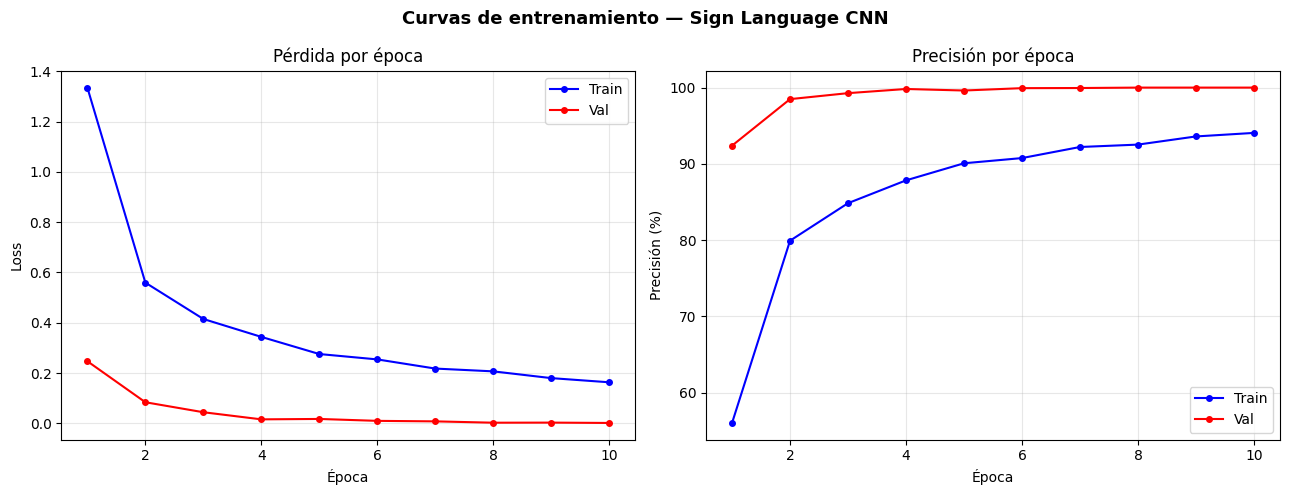

In [23]:
epochs_range = list(range(1, NUM_EPOCHS + 1))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Train')
ax1.plot(epochs_range, history['val_loss'],   'r-o', markersize=4, label='Val')
ax1.set_title('Pérdida por época'); ax1.set_xlabel('Época'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], 'b-o', markersize=4, label='Train')
ax2.plot(epochs_range, history['val_acc'],   'r-o', markersize=4, label='Val')
ax2.set_title('Precisión por época'); ax2.set_xlabel('Época'); ax2.set_ylabel('Precisión (%)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Curvas de entrenamiento — Sign Language CNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Evaluación final

Se reporta la pérdida global, la precisión global, la precisión por clase
y la **matriz de confusión**, tanto en validación como en el conjunto de test.

   EVALUACION FINAL — VALIDACION
  Perdida  : 0.0025
  Precision: 100.00%

Clase     Precision
----------------------
A           100.00%
B           100.00%
C           100.00%
D           100.00%
E           100.00%
F           100.00%
G           100.00%
H           100.00%
I           100.00%
K           100.00%
L           100.00%
M           100.00%
N           100.00%
O           100.00%
P           100.00%
Q           100.00%
R           100.00%
S           100.00%
T           100.00%
U           100.00%
V           100.00%
W           100.00%
X           100.00%
Y           100.00%

   EVALUACION FINAL — TEST
  Perdida  : 0.0460
  Precision: 98.34%

Clase     Precision
----------------------
A           100.00%
B           100.00%
C           100.00%
D           100.00%
E           100.00%
F           100.00%
G           100.00%
H            96.56%
I           100.00%
K            95.17%
L           100.00%
M            99.49%
N            99.66%
O           100.00%
P         

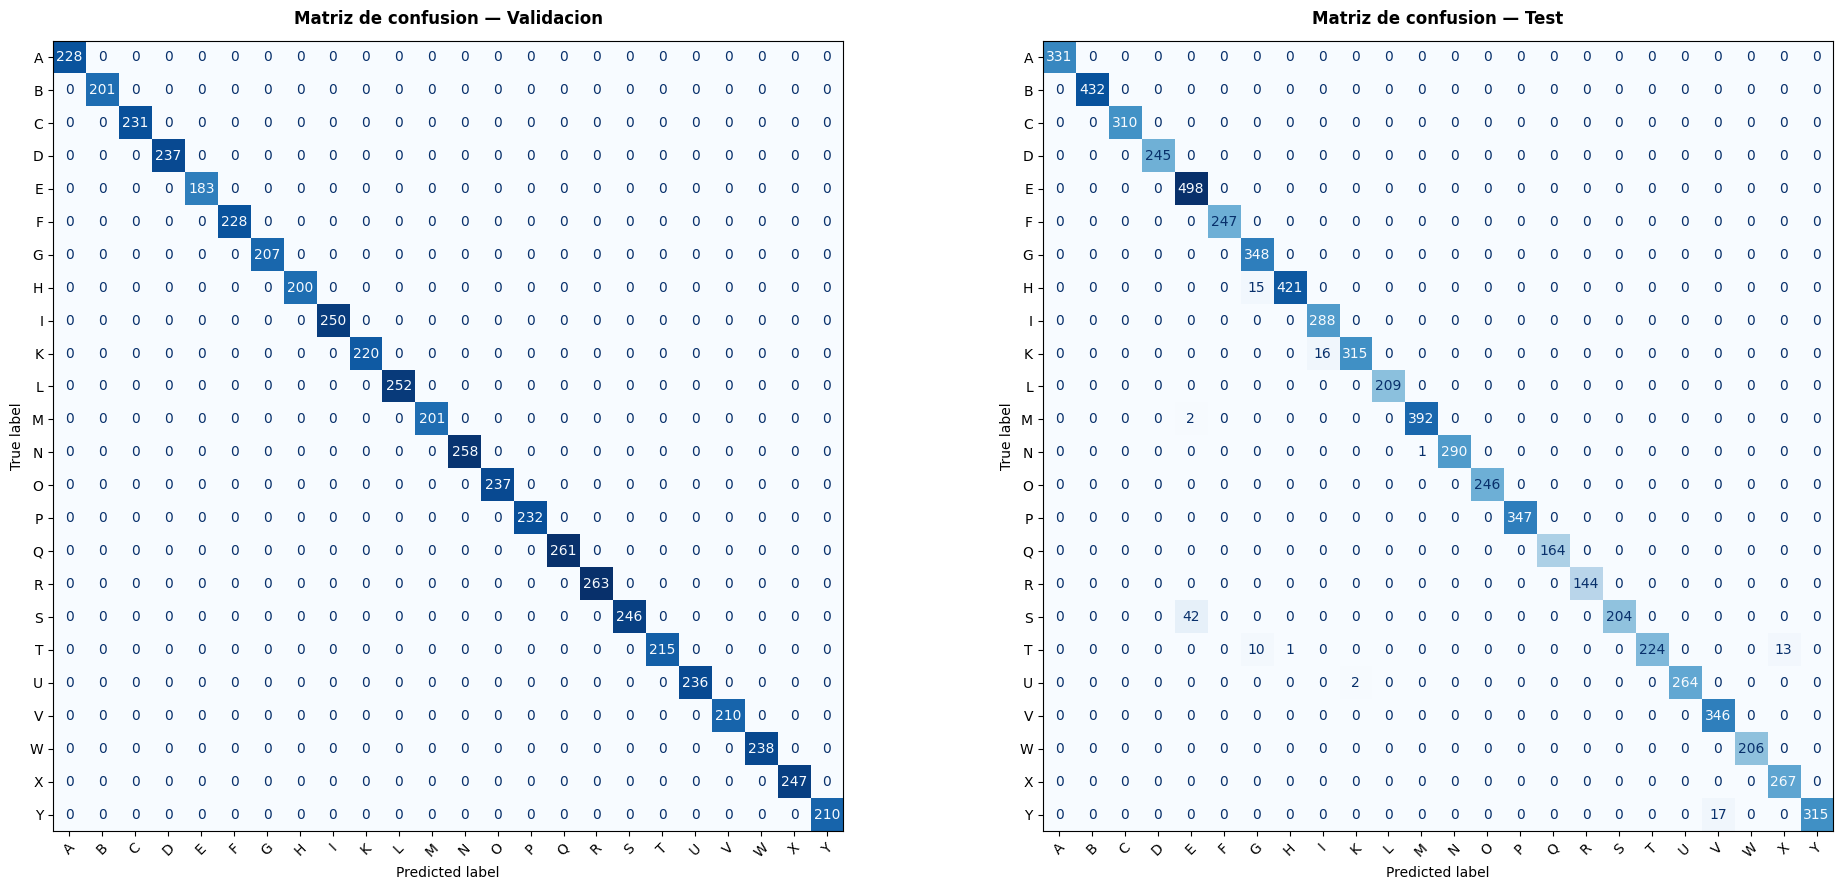

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Cargar los pesos del mejor modelo
model.load_state_dict(torch.load('best_model.pth', map_location=device))

def run_evaluation(loader, split_name):
    """Evalúa el modelo y devuelve (loss, acc, preds, labels)."""
    model.eval()
    all_preds, all_labels_ev = [], []
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs     = model(images)
            total_loss += criterion(outputs, labels).item()
            preds       = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels_ev.extend(labels.cpu().numpy())

    all_preds     = np.array(all_preds)
    all_labels_ev = np.array(all_labels_ev)
    loss = total_loss / len(loader)
    acc  = 100.0 * (all_preds == all_labels_ev).mean()

    print(f'{"=" * 50}')
    print(f'   EVALUACION FINAL — {split_name.upper()}')
    print(f'{"=" * 50}')
    print(f'  Perdida  : {loss:.4f}')
    print(f'  Precision: {acc:.2f}%')
    print(f'{"=" * 50}')
    print(f'\n{"Clase":<8} {"Precision":>10}')
    print('-' * 22)
    for i, letter in enumerate(CLASS_LETTERS):
        mask = all_labels_ev == i
        if mask.sum() == 0:
            continue
        cls_acc = 100.0 * (all_preds[mask] == all_labels_ev[mask]).mean()
        print(f'{letter:<8} {cls_acc:>9.2f}%')
    print()
    return loss, acc, all_preds, all_labels_ev

# Evaluación en validación
val_loss_f, val_acc_f, val_preds, val_true = run_evaluation(val_loader, 'validacion')

# Evaluación en test
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loss_f, test_acc_f, test_preds, test_true = run_evaluation(test_loader, 'test')

# ── Matrices de confusión — validación y test lado a lado ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, preds, true, title in [
    (axes[0], val_preds,  val_true,  'Validacion'),
    (axes[1], test_preds, test_true, 'Test'),
]:
    cm   = confusion_matrix(true, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LETTERS)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'Matriz de confusion — {title}', fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()